# Lista 1 — Regressão linear, polinomial e regularização

**Disciplina:** Aprendizagem de Máquina  
**Período:** 2026.1  
**Professor:** César Lincoln Cavalcante Mattos  
**Aluna:** Danielly Silva Paulino (MDCC)

---
#### **Instruções:**
* Com exceção dos casos explicitamente indicados, os algoritmos e modelos devem ser implementados do início em qualquer linguagem de programação.
* Pacotes auxiliares (sklearn, matplotlib, etc) podem ser usados somente para facilitar a manipulação dos dados e criar gráficos.
* Para a avaliação do trabalho, recomenda-se o envio de arquivo Jupyter notebook com os códigos executados e os resultados visíveis nas células.
---

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# **Questão 1:**
Considere o conjunto de dados disponível em `artificial1d.csv` organizado em duas colunas, x e y. Seja um modelo de regressão linear para $\hat{y}=f(x)$.

**a)** Apresente os parâmetros do modelo e o MSE (erro quadrático médio) obtidos pelo algoritmo OLS (mínimos quadrados ordinários). Plote a reta resultante sobre os dados.  
**b)** Apresente os parâmetros do modelo, o MSE e a curva de aprendizagem obtidos pelo algoritmo GD (gradiente descendente). Plote a reta resultante sobre os dados.  
**c)** Apresente os parâmetros do modelo, o MSE e a curva de aprendizagem obtidos pelo algoritmo SGD (gradiente descendente estocástico). Plote a reta resultante sobre os dados.


In [49]:
# CARREGAMENTO DOS DADOS

url_1 = "https://raw.githubusercontent.com/ddniellysilva/aprendizagem-automatica-mdcc/refs/heads/main/lista01/artificial1d.csv"
url_2 = "https://raw.githubusercontent.com/ddniellysilva/aprendizagem-automatica-mdcc/refs/heads/main/lista01/california.csv"

O dataset contém 30 linhas e 2 colunas



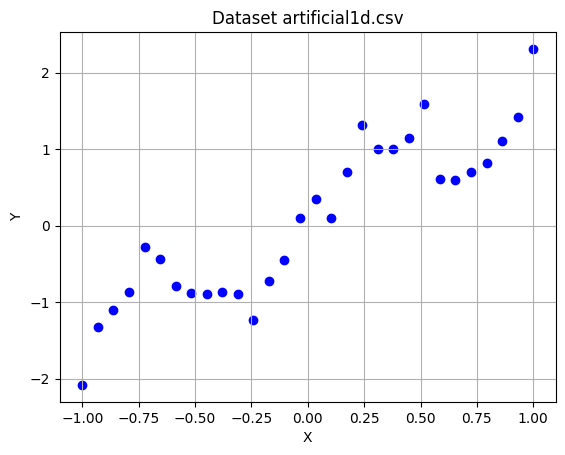

In [50]:
# ANÁLISE DO DATASET

df_1 = np.genfromtxt(url_1, delimiter=',')

r, c = df_1.shape
print(f'O dataset contém {r} linhas e {c} colunas\n')

artificial_X = df_1[:, [0]]
artificial_Y = df_1[:, [1]]

plt.scatter(artificial_X, artificial_Y, color='blue')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Dataset artificial1d.csv')
plt.grid(True)
plt.show()

In [51]:
# FUNÇÕES USADAS EM MAIS DE UM ITEM

# ERRO QUADRÁTICO MÉDIO
def calcular_mse(y: np.ndarray, y_pred: np.ndarray) -> float:
    return np.sum((y - y_pred) ** 2) / y.shape[0]


# FUNÇÃO AUXILIAR USADA NOS PLOTS
# traça a reta ajustada sobre os dados
def plotar_reta(ax, W: np.ndarray, x: np.ndarray, rotulo: str, cor: str) -> None:
    w0, w1 = float(W.ravel()[0]), float(W.ravel()[1])
    x_linha = np.linspace(x.min() - 0.1, x.max() + 0.1, 200)
    y_linha = w0 + w1 * x_linha
    ax.plot(x_linha, y_linha, color=cor, linewidth=2, label=rotulo)


# FUNÇÃO DE PLOT DA REGRESSÃO LINEAR
def plotar_regressao_linear(ax, metodo: str, x: np.ndarray, y: np.ndarray,
                            W: np.ndarray, mse: float, cor: str) -> None:
    w0, w1 = float(W.ravel()[0]), float(W.ravel()[1])
    ax.scatter(x, y, color='blue', label='Dados reais')
    plotar_reta(ax, W, x,
                rotulo=f'{metodo}  (MSE={mse:.4f})\nŷ = {w1:+.4f}x {w0:+.4f}',
                cor=cor)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'Regressão Linear via {metodo}')
    ax.legend(loc='upper left')
    ax.grid(True)


# FUNÇÃO DE PLOT DA CURVA DE APRENDIZAGEM
def plotar_curva_aprendizagem(ax, metodo: str, historico_mse: list, cor: str) -> None:
    ax.plot(historico_mse, color=cor, linewidth=1.8, label='MSE')
    ax.set_xlabel('Iterações')
    ax.set_ylabel('MSE')
    ax.set_title(f'Curva de Aprendizagem ({metodo})')
    ax.set_yscale('log')
    ax.grid(True)
    ax.legend()

In [52]:
# criar uma coluna de valores 1 para usar nos algoritmos
ones = np.ones((df_1.shape[0], 1))
artificial_X = df_1[:, [0]]
artificial_X_com_uns = np.concatenate([ones, artificial_X], axis=1)

## • resposta do item A:

In [53]:
# calcular o vetor de parâmetros
def ols(X: np.ndarray, Y: np.ndarray) -> np.ndarray:
    return np.linalg.pinv(X.T @ X) @ X.T @ Y

In [54]:
W_ols = ols(artificial_X_com_uns, artificial_Y)

print('Os parâmetros são: ', W_ols[0], W_ols[1])

Os parâmetros são:  [0.06761792] [1.57486517]


In [55]:
# calcular o Y previsto para cada linha
ols_Y_pred = artificial_X_com_uns @ W_ols

# calcular o MSE
ols_mse = calcular_mse(artificial_Y, ols_Y_pred)
print(f'O MSE é {ols_mse}')

O MSE é 0.21340090132936987


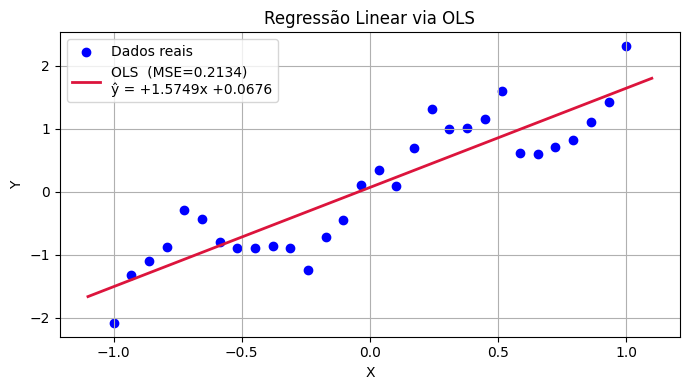

In [56]:
# exibição do gráfico
fig, ax = plt.subplots(figsize=(7, 4))
plotar_regressao_linear(ax, 'OLS', artificial_X, artificial_Y, W_ols, ols_mse, cor='crimson')
plt.tight_layout()
plt.show()

## • resposta do item B:

In [57]:
# inicializar variáveis
alpha  = 0.1   # taxa de aprendizado
epocas = 500   # número de iterações
print('INICIALIZAÇÃO')
print('Taxa de aprendizado: ', alpha)
print('Número de iterações: ', epocas)

gd_historico_mse = []

# iniciar parâmetros com 0
W = np.zeros((artificial_X_com_uns.shape[1], 1))
print('Parâmetros: ', W[0], W[1])

# gradiente descendente
for i in range(epocas):
    # calcular os valores previstos com os parâmetros atuais
    gd_Y_pred = artificial_X_com_uns @ W

    # obter o erro
    erro = gd_Y_pred - artificial_Y

    # calcular o gradiente (negativo, para subtrair na direção do mínimo)
    gradiente = -(1 / artificial_Y.shape[0]) * (artificial_X_com_uns.T @ erro)

    # atualizar os parâmetros
    W = W + alpha * gradiente

    gd_historico_mse.append(calcular_mse(artificial_Y, gd_Y_pred))

print('')
print('RESULTADOS')
print('Os parâmetros são: ', W[0], W[1])

# última previsão
W_gd    = W
gd_Y_pred = artificial_X_com_uns @ W_gd

# calcular o MSE final
gd_mse = calcular_mse(artificial_Y, gd_Y_pred)
print(f'O MSE é {gd_mse}')

INICIALIZAÇÃO
Taxa de aprendizado:  0.1
Número de iterações:  500
Parâmetros:  [0.] [0.]

RESULTADOS
Os parâmetros são:  [0.06761792] [1.57486515]
O MSE é 0.2134009013293701


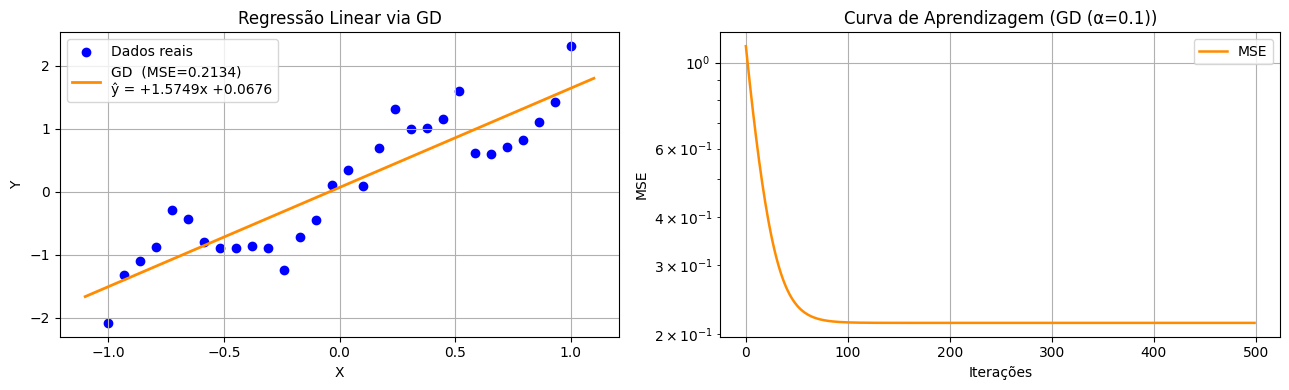

In [58]:
# regressão linear e curva de aprendizagem
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plotar_regressao_linear(axes[0], 'GD', artificial_X, artificial_Y, W_gd, gd_mse, cor='darkorange')
plotar_curva_aprendizagem(axes[1], f'GD (α={alpha})', gd_historico_mse, cor='darkorange')

plt.tight_layout()
plt.show()

## • resposta do item C:

In [59]:
# inicializar variáveis
alpha  = 0.05  # taxa de aprendizado
epocas = 200   # número de iterações
print('INICIALIZAÇÃO')
print('Taxa de aprendizado: ', alpha)
print('Número de iterações: ', epocas)

sgd_historico_mse = []

# iniciar parâmetros com 0
W = np.zeros((artificial_X_com_uns.shape[1], 1))
print('Parâmetros: ', W[0], W[1])

# gradiente descendente estocástico
for e in range(epocas):
    # permutar aleatoriamente os dados e iterar sobre eles
    indices = np.random.permutation(artificial_Y.shape[0])
    for idx in indices:
        xi = artificial_X_com_uns[idx].reshape(1, -1)  # precisa do reshape para o shape (1, 2)
        yi = artificial_Y[idx]

        # calcular o valor previsto e seu erro para o dado atual
        yi_pred = xi @ W
        erro    = yi_pred - yi

        # atualizar os parâmetros
        gradiente = -xi.T * erro
        W = W + alpha * gradiente

    # calcular os valores previstos com os parâmetros atuais
    sgd_Y_pred = artificial_X_com_uns @ W

    # calcular o mse atual
    sgd_historico_mse.append(calcular_mse(artificial_Y, sgd_Y_pred))

# a previsão e o MSE final serão os da última iteração
print('')
print('RESULTADOS')
print('Os parâmetros são: ', W[0], W[1])

W_sgd     = W
sgd_Y_pred = artificial_X_com_uns @ W_sgd
sgd_mse   = sgd_historico_mse[-1]
print(f'O MSE é {sgd_mse}')

INICIALIZAÇÃO
Taxa de aprendizado:  0.05
Número de iterações:  200
Parâmetros:  [0.] [0.]

RESULTADOS
Os parâmetros são:  [0.03384747] [1.58851949]
O MSE é 0.21460777791062052


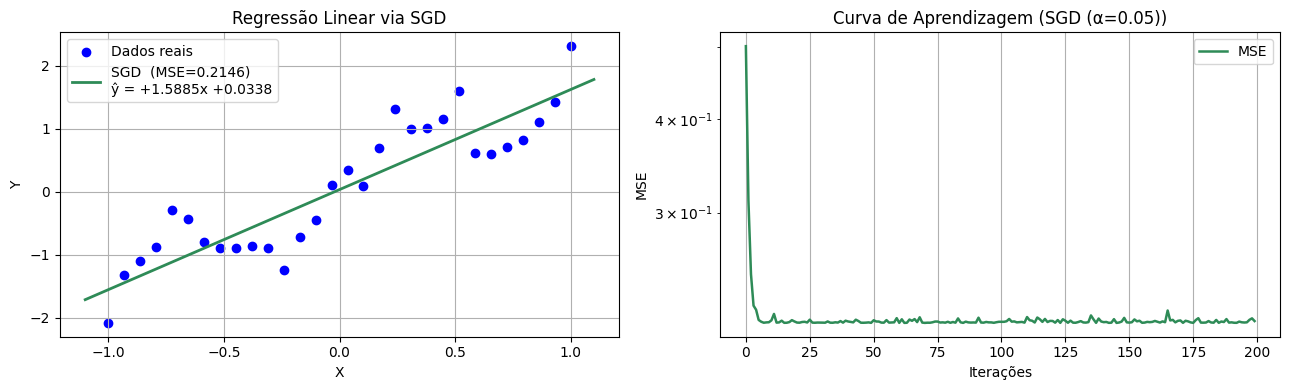

In [60]:
# regressão linear e curva de aprendizagem
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plotar_regressao_linear(axes[0], 'SGD', artificial_X, artificial_Y, W_sgd, sgd_mse, cor='seagreen')
plotar_curva_aprendizagem(axes[1], f'SGD (α={alpha})', sgd_historico_mse, cor='seagreen')

plt.tight_layout()
plt.show()

## • comparativo dos resultados:

In [61]:
# tabela comparativa
print(f'{"Algoritmo":>10}  {"w0":>12}  {"w1":>12}  {"MSE":>12}')
print('─' * 52)
for nome, W_alg, mse_alg in [("OLS", W_ols, ols_mse), ("GD", W_gd, gd_mse), ("SGD", W_sgd, sgd_mse)]:
    print(f'{nome:>10}  {float(W_alg.ravel()[0]):>12.6f}  {float(W_alg.ravel()[1]):>12.6f}  {mse_alg:>12.6f}')

 Algoritmo            w0            w1           MSE
────────────────────────────────────────────────────
       OLS      0.067618      1.574865      0.213401
        GD      0.067618      1.574865      0.213401
       SGD      0.033847      1.588519      0.214608


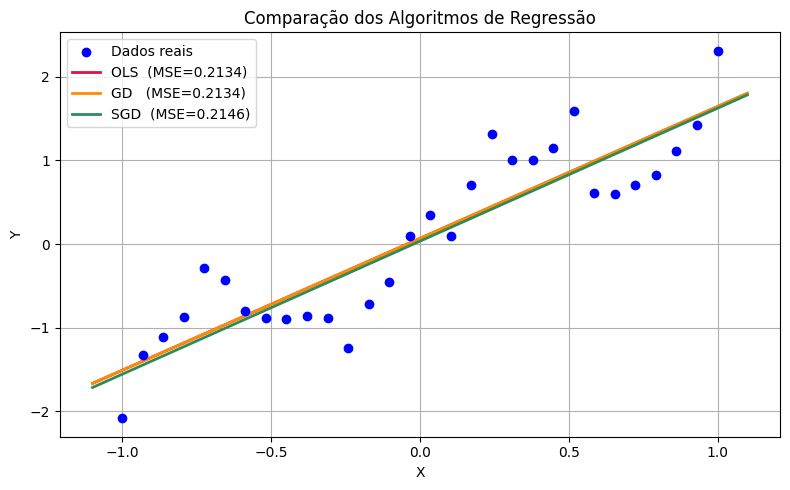

In [62]:
# gráfico comparativo: todas as retas sobre os dados
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(artificial_X, artificial_Y, color='blue', label='Dados reais', zorder=3)
plotar_reta(ax, W_ols, artificial_X, rotulo=f'OLS  (MSE={ols_mse:.4f})', cor='crimson')
plotar_reta(ax, W_gd,  artificial_X, rotulo=f'GD   (MSE={gd_mse:.4f})',  cor='darkorange')
plotar_reta(ax, W_sgd, artificial_X, rotulo=f'SGD  (MSE={sgd_mse:.4f})', cor='seagreen')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Comparação dos Algoritmos de Regressão')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# **Questão 2:**
Considere o conjunto de dados disponível em `california.csv`, organizado em 9 colunas, sendo as 8 primeiras colunas os atributos e a última coluna a saída. Os 8 atributos são usados na predição da mediana de preços de casas em distritos da Califórnia na década de 1990. Maiores detalhes sobre os dados podem ser conferidos em [https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset).

**a)** Aleatoriamente, divida o conjunto de dados em treino (80%) e teste (20%).  
**b)** Treine 13 modelos de regressão polinomial, com ordens de 1 a 13. Você pode usar o algoritmo OLS.  
**c)** Reporte o RMSE (raiz quadrada do erro quadrático médio) no treinamento e no teste para cada modelo. Faça um gráfico para o treino e um gráfico para o teste.  
**d)** Repita os 2 itens anteriores incluindo um termo de regularização L2 (por exemplo, com fator $\lambda=0.01$).  

> **Nota:** Normalize os dados (a saída com StandardScaler e as entradas com MinMax) antes do treinamento/teste (antes de criar os regressores polinomiais) e "desnormalize" a saída antes de calcular o RMSE.

In [63]:
# ANÁLISE DO DATASET

df_2 = np.genfromtxt(url_2, delimiter=',')

r, c = df_2.shape
print(f'O dataset contém {r} linhas e {c} colunas\n')

california_X = df_2[:, 0:8]   # colunas 0 a 7 (atributos)
california_Y = df_2[:, [8]]   # última coluna (alvo)

print('california_X:', california_X.shape)
print('california_Y:', california_Y.shape)

O dataset contém 1000 linhas e 9 colunas

california_X: (1000, 8)
california_Y: (1000, 1)


In [64]:
# FUNÇÕES USADAS EM MAIS DE UM ITEM (NORMALIZAÇÃO)

def media(dados: np.ndarray) -> np.ndarray:
    return dados.sum(axis=0) / dados.shape[0]

def desvio_padrao(dados: np.ndarray, media_dados: np.ndarray) -> np.ndarray:
    d = ((dados - media_dados) ** 2).sum(axis=0)
    return np.sqrt(d / (dados.shape[0] - 1))

def normalizar_standard_scaler(dados: np.ndarray, media_dados=None, dp_dados=None):
    # Normalização Z-score. Retorna (dados_norm, media, desvio_padrao)
    media_dados = media_dados if media_dados is not None else media(dados)
    dp_dados    = dp_dados    if dp_dados    is not None else desvio_padrao(dados, media_dados)
    dados_norm  = (dados - media_dados) / dp_dados
    return dados_norm, media_dados, dp_dados

def desnormalizar_standard_scaler(dados: np.ndarray,
                                   media_dados: np.ndarray,
                                   dp_dados: np.ndarray) -> np.ndarray:
    # Inverte a normalização Z-score
    return dp_dados * dados + media_dados

def normalizar_min_max(dados: np.ndarray, epsilon: float, minimo=None, maximo=None):
    # Normalização Min-Max. Retorna (dados_norm, minimo, maximo)
    minimo = minimo if minimo is not None else np.min(dados, axis=0)
    maximo = maximo if maximo is not None else np.max(dados, axis=0)
    dados_norm = (dados - minimo) / (maximo - minimo + epsilon)
    return dados_norm, minimo, maximo

In [65]:
# FUNÇÕES USADAS EM MAIS DE UM ITEM (PLOTAGEM)

def plotar_rmse(rmses_treino: list, rmses_teste: list, titulo: str = '') -> None:
    graus = list(range(1, len(rmses_treino) + 1))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for ax, rmses, label, cor in [
        (axes[0], rmses_treino, 'Treino', 'royalblue'),
        (axes[1], rmses_teste,  'Teste',  'crimson'),
    ]:
        ax.plot(graus, rmses, color=cor, marker='o', linewidth=1.8,
                markersize=6, label=label)
        ax.set_xlabel('Grau do Modelo')
        ax.set_ylabel('RMSE')
        ax.set_title(f'RMSE — {label} {titulo}')
        ax.set_xticks(graus)
        ax.grid(True, alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend()

    if titulo:
        plt.suptitle(titulo, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


def plotar_comparativo_l2(rmses_treino: list, rmses_teste: list,
                           rmses_treino_l2: list, rmses_teste_l2: list,
                           lambda_: float) -> None:
    graus = list(range(1, len(rmses_treino) + 1))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    configs = [
        (axes[0], rmses_treino, rmses_treino_l2, 'royalblue', 'darkorange', 'Treino'),
        (axes[1], rmses_teste,  rmses_teste_l2,  'crimson',   'seagreen',   'Teste'),
    ]
    for ax, sem_l2, com_l2, cor1, cor2, label in configs:
        ax.plot(graus, sem_l2, color=cor1, marker='o', linewidth=1.8,
                markersize=6, label='Sem L2')
        ax.plot(graus, com_l2, color=cor2, marker='s', linewidth=1.8,
                markersize=6, linestyle='--', label=f'Com L2 (λ={lambda_})')
        ax.set_xlabel('Grau do Modelo')
        ax.set_ylabel('RMSE')
        ax.set_title(f'RMSE — {label}: Sem L2 vs Com L2')
        ax.set_xticks(graus)
        ax.grid(True, alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend()

    plt.suptitle('Comparativo: Sem Regularização vs L2', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

## • resposta do item A:

In [66]:
# divisão treino/teste
semente_aleatoria = 123
tamanho_teste     = 0.2
EPSILON_MIN_MAX   = 1e-5

np.random.seed(semente_aleatoria)
n       = california_X.shape[0]
indices = np.random.permutation(n)

# índices de treino e teste
qtd_teste      = int(n * tamanho_teste)
indices_teste  = indices[:qtd_teste]
indices_treino = indices[qtd_teste:]

# Y treino: normalizar com StandardScaler
california_Y_treino_desnorm = california_Y[indices_treino]
california_Y_treino_norm, california_Y_treino_media, california_Y_treino_dp = \
    normalizar_standard_scaler(california_Y_treino_desnorm)

# X treino: normalizar com MinMax
california_X_treino_desnorm = california_X[indices_treino]
california_X_treino_norm, california_X_treino_min, california_X_treino_max = \
    normalizar_min_max(california_X_treino_desnorm, EPSILON_MIN_MAX)

# Y teste: sem normalizar (usado para calcular o RMSE final)
california_Y_teste_desnorm = california_Y[indices_teste]

# X teste: normalizar com os parâmetros do treino
california_X_teste_desnorm = california_X[indices_teste]
california_X_teste_norm, _, _ = normalizar_min_max(
    california_X_teste_desnorm, EPSILON_MIN_MAX,
    california_X_treino_min, california_X_treino_max
)

print('X treino normalizado:', california_X_treino_norm.shape)
print('Y treino normalizado:', california_Y_treino_norm.shape)
print('\nX teste normalizado: ', california_X_teste_norm.shape)
print('Y teste (desnorm):   ', california_Y_teste_desnorm.shape)

X treino normalizado: (800, 8)
Y treino normalizado: (800, 1)

X teste normalizado:  (200, 8)
Y teste (desnorm):    (200, 1)


## • resposta do item B:

In [67]:
# cria features polinomiais com base no grau especificado
def features_polinomiais(X: np.ndarray, grau: int) -> np.ndarray:
    n        = X.shape[0]
    features = [X ** d for d in range(1, grau + 1)]
    col_uns  = np.ones((n, 1))
    return np.concatenate([col_uns, *features], axis=1)

# realiza a regressão polinomial encontrando os parâmetros via OLS
def ols_regressao_polinomial(X: np.ndarray, Y: np.ndarray, grau: int) -> tuple:
    X_poly = features_polinomiais(X, grau)
    W      = ols(X_poly, Y)   # ols definido na Questão 1
    return W, X_poly

In [68]:
# treinando modelos com grau de 1 a 13
modelos_polinomiais = [
    ols_regressao_polinomial(california_X_treino_norm, california_Y_treino_norm, grau)
    for grau in range(1, 14)
]

for grau, (W, X_poly) in enumerate(modelos_polinomiais, start=1):
    print(f'Modelo de grau {grau}:')
    print('  Parâmetros:', W.T[0])
    print('  Shape de X:', X_poly.shape)
    print()

Modelo de grau 1:
  Parâmetros: [ 1.9588889   4.6055598   0.55739507 -1.69442497  2.58259465  0.2984075
 -2.12312493 -3.66941431 -3.46702778]
  Shape de X: (800, 9)

Modelo de grau 2:
  Parâmetros: [ 1.91104506  5.58610453  0.8889576  -2.70141948  5.39610997  1.09614024
 -4.71639011 -4.88314706 -2.77664183 -1.28666993 -0.22354672  3.7653646
 -6.66721935 -0.85214989  4.41522252  1.3849961  -0.86150791]
  Shape de X: (800, 17)

Modelo de grau 3:
  Parâmetros: [ 1.94804261e+00  2.78946716e+00  2.00883208e+00 -8.63734657e+00
  1.01129805e+01  9.18134773e-01 -7.91164791e+00 -3.12515328e+00
 -1.73971907e-01  7.47140456e+00 -2.59523630e+00  2.92290736e+01
 -3.01895838e+01  1.35033924e-02  1.42321693e+01 -3.66223935e+00
 -7.06292250e+00 -7.16973571e+00  1.45328985e+00 -2.12697132e+01
  2.09853611e+01 -8.36480342e-01 -7.52092826e+00  3.90517089e+00
  4.28770861e+00]
  Shape de X: (800, 25)

Modelo de grau 4:
  Parâmetros: [  1.19621362   2.53955742   2.09692237 -11.31690277  17.97011723
   1.98

## • resposta do item C:

In [69]:
# raiz do erro quadrático médio
def calcular_rmse(y: np.ndarray, y_pred: np.ndarray) -> float:
    return np.sqrt(calcular_mse(y, y_pred))   # calcular_mse definido na Questão 1

In [70]:
todos_rmse_treino = []
todos_rmse_teste  = []

for grau, (W, X_treino_poly) in enumerate(modelos_polinomiais, start=1):
    print('Modelo', grau)

    # TREINO
    y_treino_pred_norm    = X_treino_poly @ W
    y_treino_pred_desnorm = desnormalizar_standard_scaler(
        y_treino_pred_norm, california_Y_treino_media, california_Y_treino_dp)
    rmse_treino = calcular_rmse(california_Y_treino_desnorm, y_treino_pred_desnorm)
    todos_rmse_treino.append(float(rmse_treino))
    print('  RMSE treino:', rmse_treino)

    # TESTE
    X_teste_poly          = features_polinomiais(california_X_teste_norm, grau)
    y_teste_pred_norm     = X_teste_poly @ W
    y_teste_pred_desnorm  = desnormalizar_standard_scaler(
        y_teste_pred_norm, california_Y_treino_media, california_Y_treino_dp)
    rmse_teste = calcular_rmse(california_Y_teste_desnorm, y_teste_pred_desnorm)
    todos_rmse_teste.append(float(rmse_teste))
    print('  RMSE teste: ', rmse_teste)

Modelo 1
  RMSE treino: 0.6835102597817971
  RMSE teste:  0.6189635147154662
Modelo 2
  RMSE treino: 0.6612272219583607
  RMSE teste:  0.5976562824977819
Modelo 3
  RMSE treino: 0.6414626698429147
  RMSE teste:  0.5604744786961122
Modelo 4
  RMSE treino: 0.6350157752730102
  RMSE teste:  0.5441455015321008
Modelo 5
  RMSE treino: 0.6271334142319747
  RMSE teste:  0.532588374052154
Modelo 6
  RMSE treino: 0.6166960625049678
  RMSE teste:  0.7190844523509384
Modelo 7
  RMSE treino: 0.6105268908744084
  RMSE teste:  0.6832019612909258
Modelo 8
  RMSE treino: 0.6070275357860679
  RMSE teste:  2.8069540381836204
Modelo 9
  RMSE treino: 0.6034262992365278
  RMSE teste:  8.432959676477928
Modelo 10
  RMSE treino: 0.6037524904968898
  RMSE teste:  9.195638694627453
Modelo 11
  RMSE treino: 0.5989995088368248
  RMSE teste:  3.1377199837239296
Modelo 12
  RMSE treino: 0.5975343016713722
  RMSE teste:  6.244977754887224
Modelo 13
  RMSE treino: 0.5953534055185633
  RMSE teste:  17.66171010264227


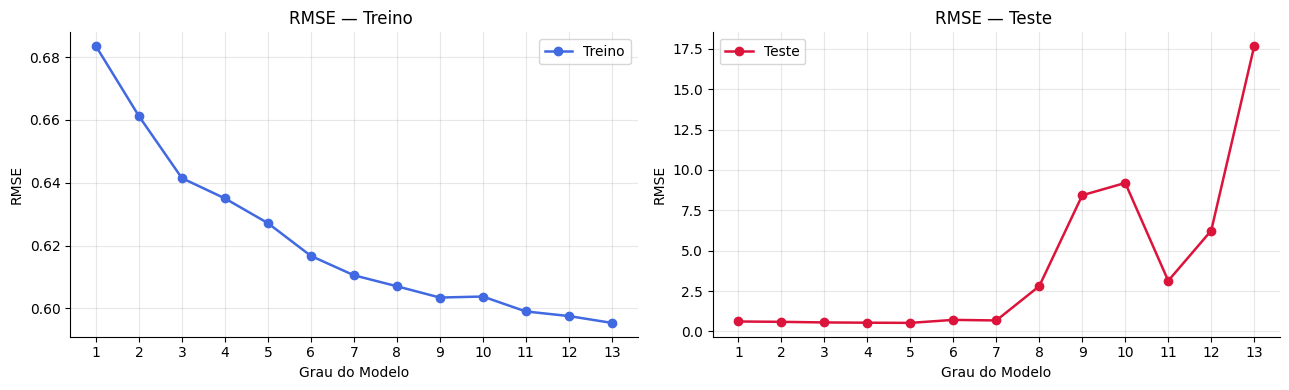

In [71]:
# gráfico do RMSE no treino e no teste
plotar_rmse(todos_rmse_treino, todos_rmse_teste)

## • resposta do item D:

In [72]:
def ols_regressao_polinomial_l2(X: np.ndarray, Y: np.ndarray,
                                 grau: int, lambda_: float) -> tuple:
    X_poly     = features_polinomiais(X, grau)
    n_features = X_poly.shape[1]

    # matriz identidade sem regularizar o viés (posição [0,0])
    identidade       = np.eye(n_features)
    identidade[0, 0] = 0

    # solução fechada com L2: W = (XᵗX + λI)⁻¹ Xᵗy
    W = np.linalg.pinv(X_poly.T @ X_poly + lambda_ * identidade) @ X_poly.T @ Y
    return W, X_poly

In [73]:
# inicializar variáveis
LAMBDA = 0.01
print('INICIALIZAÇÃO')
print('Fator de regularização λ:', LAMBDA)
print()

# treinando modelos com grau de 1 a 13 com regularização L2
modelos_polinomiais_l2 = [
    ols_regressao_polinomial_l2(california_X_treino_norm, california_Y_treino_norm, grau, LAMBDA)
    for grau in range(1, 14)
]

for grau, (W, X_poly) in enumerate(modelos_polinomiais_l2, start=1):
    print(f'Modelo de grau {grau} (L2):')
    print('  Parâmetros:', W.T[0])
    print('  Shape de X:', X_poly.shape)
    print()

INICIALIZAÇÃO
Fator de regularização λ: 0.01

Modelo de grau 1 (L2):
  Parâmetros: [ 1.95658228  4.5882655   0.5581366  -1.63946741  2.51808792  0.29591472
 -2.12336528 -3.66463359 -3.46028818]
  Shape de X: (800, 9)

Modelo de grau 2 (L2):
  Parâmetros: [ 1.94396771  5.44534182  0.85421799 -2.25177483  4.80393646  1.06100929
 -4.67138349 -4.8374964  -2.79751132 -1.15796951 -0.19685252  2.90450588
 -5.50890315 -0.82638346  4.33730628  1.31867901 -0.83664213]
  Shape de X: (800, 17)

Modelo de grau 3 (L2):
  Parâmetros: [ 1.99506557  2.7572261   2.01359256 -2.89932743  4.60864655  1.04905119
 -6.28014875 -3.75788242 -1.43531358  7.12508122 -2.80123056  6.23535771
 -6.39960547 -0.37855711  9.419436   -1.77777208 -4.05916056 -6.61680491
  1.6407684  -3.58271044  1.98066108 -0.54699212 -3.95111581  2.35398018
  2.21217449]
  Shape de X: (800, 25)

Modelo de grau 4 (L2):
  Parâmetros: [ 2.04715867  3.13030385  1.64795053 -3.12321649  4.71304072  1.023952
 -6.32280406 -3.69041675 -1.42223112

In [74]:
todos_rmse_treino_l2 = []
todos_rmse_teste_l2  = []

for grau, (W, X_treino_poly) in enumerate(modelos_polinomiais_l2, start=1):
    print('Modelo', grau, '(L2)')

    # TREINO
    y_treino_pred_norm    = X_treino_poly @ W
    y_treino_pred_desnorm = desnormalizar_standard_scaler(
        y_treino_pred_norm, california_Y_treino_media, california_Y_treino_dp)
    rmse_treino = calcular_rmse(california_Y_treino_desnorm, y_treino_pred_desnorm)
    todos_rmse_treino_l2.append(float(rmse_treino))
    print('  RMSE treino:', rmse_treino)

    # TESTE
    X_teste_poly          = features_polinomiais(california_X_teste_norm, grau)
    y_teste_pred_norm     = X_teste_poly @ W
    y_teste_pred_desnorm  = desnormalizar_standard_scaler(
        y_teste_pred_norm, california_Y_treino_media, california_Y_treino_dp)
    rmse_teste = calcular_rmse(california_Y_teste_desnorm, y_teste_pred_desnorm)
    todos_rmse_teste_l2.append(float(rmse_teste))
    print('  RMSE teste: ', rmse_teste)

Modelo 1 (L2)
  RMSE treino: 0.6835145703598061
  RMSE teste:  0.6192537051264243
Modelo 2 (L2)
  RMSE treino: 0.6614014267316849
  RMSE teste:  0.5994412762680223
Modelo 3 (L2)
  RMSE treino: 0.6480021906216069
  RMSE teste:  0.5739237859398112
Modelo 4 (L2)
  RMSE treino: 0.6453287709902756
  RMSE teste:  0.5787514033547713
Modelo 5 (L2)
  RMSE treino: 0.6444949919599877
  RMSE teste:  0.5841134722966758
Modelo 6 (L2)
  RMSE treino: 0.6444528969293799
  RMSE teste:  0.5832018991574812
Modelo 7 (L2)
  RMSE treino: 0.6442694100845543
  RMSE teste:  0.5751189040987771
Modelo 8 (L2)
  RMSE treino: 0.6436097353492801
  RMSE teste:  0.5647850792180971
Modelo 9 (L2)
  RMSE treino: 0.6426112310319463
  RMSE teste:  0.5607976776701467
Modelo 10 (L2)
  RMSE treino: 0.6415498772977768
  RMSE teste:  0.5758069985155638
Modelo 11 (L2)
  RMSE treino: 0.6406117216711442
  RMSE teste:  0.625258221959366
Modelo 12 (L2)
  RMSE treino: 0.6398629287888187
  RMSE teste:  0.7222740230088456
Modelo 13 (L2)

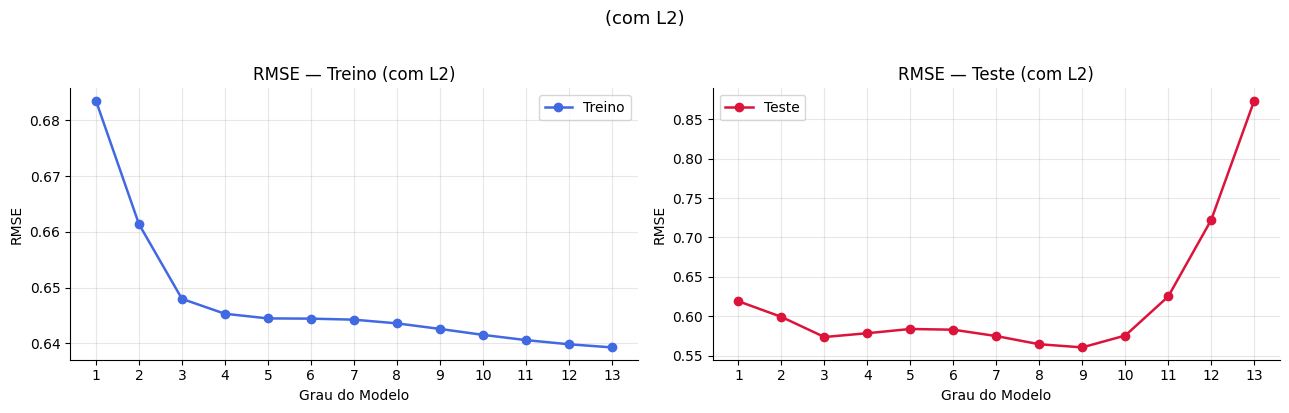

In [75]:
# gráfico do RMSE no treino e no teste com L2
plotar_rmse(todos_rmse_treino_l2, todos_rmse_teste_l2, '(com L2)')